<a href="https://colab.research.google.com/github/rmadatt/ADLAB/blob/main/A_GPU_memory_footprint_chart_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

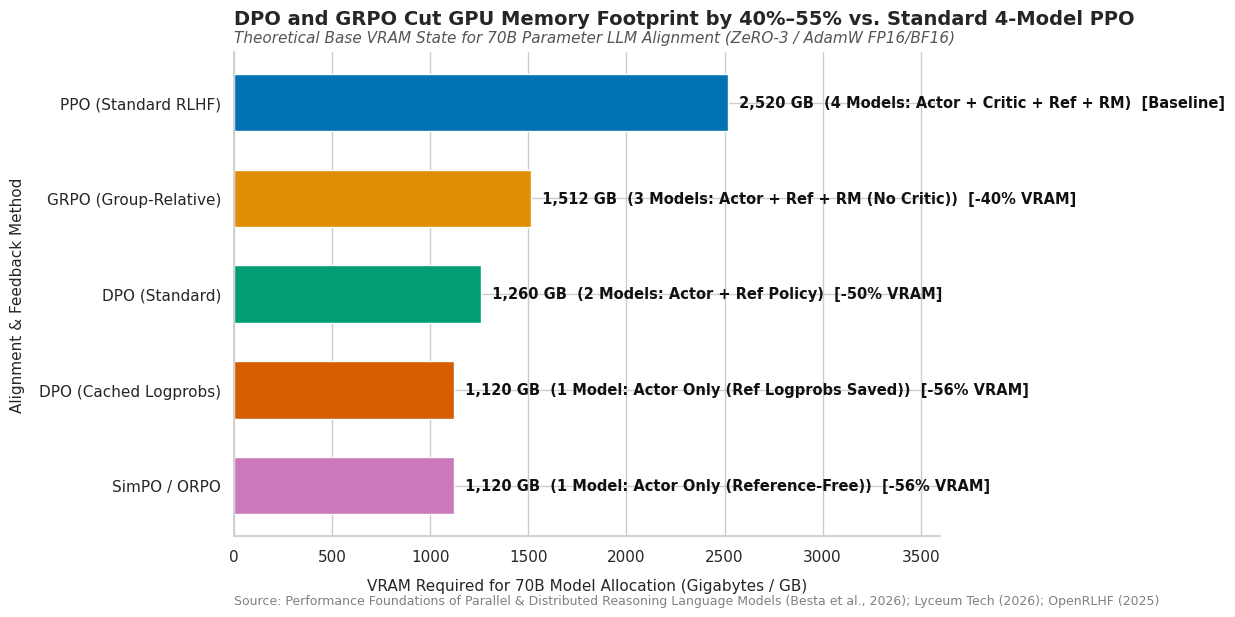

In [4]:
# A GPU memory footprint chart (`vram_footprint_chart.png`) comparing **VRAM allocation across LLM alignment & feedback methods** has been generated and published to your Studio panel.

# DPO and GRPO reduce GPU memory requirements by 40% to 55% compared to standard 4-model PPO** for a 70B parameter model. While traditional RLHF (PPO) requires hosting **2,520 GB** of state memory across four concurrent models (Actor, Critic, Reference, and Reward Model), **DPO cuts state memory to 1,260 GB** (2 models), and **GRPO operates at 1,512 GB** by eliminating the value critic. With offline reference log-probability caching or reference-free objectives (SimPO/ORPO), the active footprint drops to a single model (**1,120 GB**).

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Configure Seaborn theme and accessibility defaults
sns.set_theme(style='whitegrid', palette='colorblind', font='DejaVu Sans')

# 2. Alignment VRAM footprint data (70B parameter model allocation)
alignment_vram_data = [
    {
        'Method': 'PPO (Standard RLHF)',
        'VRAM_70B_GB': 2520,
        'Active_Models': 4,
        'Models_Detail': 'Actor + Critic + Ref + RM',
        'Type': 'On-Policy RL'
    },
    {
        'Method': 'GRPO (Group-Relative)',
        'VRAM_70B_GB': 1512,
        'Active_Models': 3,
        'Models_Detail': 'Actor + Ref + RM (No Critic)',
        'Type': 'On-Policy RL (Critic-Free)'
    },
    {
        'Method': 'DPO (Standard)',
        'VRAM_70B_GB': 1260,
        'Active_Models': 2,
        'Models_Detail': 'Actor + Ref Policy',
        'Type': 'Offline Contrastive'
    },
    {
        'Method': 'DPO (Cached Logprobs)',
        'VRAM_70B_GB': 1120,
        'Active_Models': 1,
        'Models_Detail': 'Actor Only (Ref Logprobs Saved)',
        'Type': 'Offline Contrastive'
    },
    {
        'Method': 'SimPO / ORPO',
        'VRAM_70B_GB': 1120,
        'Active_Models': 1,
        'Models_Detail': 'Actor Only (Reference-Free)',
        'Type': 'Offline Reference-Free'
    }
]

df = pd.DataFrame(alignment_vram_data)
df['Savings_vs_PPO'] = ((2520 - df['VRAM_70B_GB']) / 2520 * 100).round(1)

# 3. Create Figure & Axes
fig, ax = plt.subplots(figsize=(12, 6.5))

colors = sns.color_palette('colorblind', len(df))
bars = ax.barh(df['Method'], df['VRAM_70B_GB'], color=colors, height=0.6)

# 4. Annotate bar values, model headcounts, and savings
for bar, (index, row_series) in zip(bars, df.iterrows()): # Unpack the tuple correctly
    val = row_series['VRAM_70B_GB'] # Access from the Series
    models = row_series['Active_Models'] # Access from the Series
    detail = row_series['Models_Detail'] # Access from the Series
    savings = row_series['Savings_vs_PPO'] # Access from the Series

    label_text = f" {val:,} GB  ({models} {'Model' if models==1 else 'Models'}: {detail})"
    label_text += f"  [-{savings:.0f}% VRAM]" if savings > 0 else "  [Baseline]"

    ax.text(val + 30, bar.get_y() + bar.get_height()/2, label_text,
            va='center', ha='left', fontsize=10.5, fontweight='bold', color='#111111')

# 5. Styling & Labels
ax.set_title("DPO and GRPO Cut GPU Memory Footprint by 40%–55% vs. Standard 4-Model PPO",
             fontsize=14, fontweight='bold', pad=20, loc='left')

ax.text(0, 1.02, "Theoretical Base VRAM State for 70B Parameter LLM Alignment (ZeRO-3 / AdamW FP16/BF16)",
        transform=ax.transAxes, fontsize=11, color='#555555', style='italic')

ax.set_xlim(0, 3600)
ax.set_xlabel("VRAM Required for 70B Model Allocation (Gigabytes / GB)", fontsize=11, labelpad=10)
ax.set_ylabel("Alignment & Feedback Method", fontsize=11, labelpad=10)
ax.invert_yaxis()  # Keep baseline at top

sns.despine(top=True, right=True)

ax.text(0.0, -0.14, "Source: Performance Foundations of Parallel & Distributed Reasoning Language Models (Besta et al., 2026); Lyceum Tech (2026); OpenRLHF (2025)",
        transform=ax.transAxes, fontsize=9, color='gray', ha='left')

plt.tight_layout(pad=1.5)
plt.show()